In [1]:
# ====================================================================
# PHẦN 3: PHÂN TÍCH CẤU TRÚC MẠNG (NETWORK STRUCTURE ANALYSIS)
# ====================================================================
# Dataset: Facebook Social Circles from Stanford SNAP
# Phân tích: Centrality measures, PageRank, HITS, Correlation
# ====================================================================

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
import warnings
import os
warnings.filterwarnings('ignore')

# Cấu hình matplotlib
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 1. Tải Dữ Liệu

**Dataset**: Facebook Social Circles (4,039 nodes, 88,234 edges)

In [2]:
# Load network từ Stanford SNAP
data_dir = '../data'
gexf_file = f'{data_dir}/social_network.gexf'

print("Loading Facebook Social Circles dataset...")
if os.path.exists(gexf_file):
    G = nx.read_gexf(gexf_file)
    G = nx.convert_node_labels_to_integers(G)
    print("✓ Dataset loaded successfully!")
else:
    raise FileNotFoundError(f"File not found: {gexf_file}\nRun: python ../scripts/data_collection.py")

n_nodes = G.number_of_nodes()
m_edges = G.number_of_edges()
print(f"\nNetwork: {n_nodes:,} nodes, {m_edges:,} edges")
print(f"Type: {'Directed' if G.is_directed() else 'Undirected'}")

# Sử dụng largest connected component nếu không liên thông
if not nx.is_connected(G):
    print("\n⚠ Graph disconnected. Using largest connected component...")
    largest_cc = max(nx.connected_components(G), key=len)
    G = G.subgraph(largest_cc).copy()
    print(f"✓ Working with: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Loading Facebook Social Circles dataset...
✓ Dataset loaded successfully!

Network: 4,039 nodes, 88,234 edges
Type: Undirected
✓ Dataset loaded successfully!

Network: 4,039 nodes, 88,234 edges
Type: Undirected


## 2. Tính Các Độ Đo Trung Tâm (Centrality Measures)

In [3]:
print("="*70)
print("TÍNH TOÁN CÁC ĐỘ ĐO TRUNG TÂM")
print("="*70)

# 1. Degree Centrality (Trung tâm theo bậc)
print("\n1. Tính Degree Centrality...")
degree_centrality = nx.degree_centrality(G)

# 2. Closeness Centrality (Trung tâm theo độ gần)
print("2. Tính Closeness Centrality...")
if nx.is_connected(G):
    closeness_centrality = nx.closeness_centrality(G)
else:
    # Tính cho từng thành phần liên thông
    closeness_centrality = {}
    for component in nx.connected_components(G):
        subgraph = G.subgraph(component)
        closeness = nx.closeness_centrality(subgraph)
        closeness_centrality.update(closeness)

# 3. Betweenness Centrality (Trung tâm theo khoảng cách)
print("3. Tính Betweenness Centrality...")
betweenness_centrality = nx.betweenness_centrality(G, normalized=True)

# 4. Eigenvector Centrality (Trung tâm theo trị riêng)
print("4. Tính Eigenvector Centrality...")
try:
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)
except:
    print("   Không hội tụ, sử dụng eigenvector_centrality_numpy...")
    eigenvector_centrality = nx.eigenvector_centrality_numpy(G)

print("\n✓ Hoàn thành tính toán các độ đo trung tâm cơ bản!")

TÍNH TOÁN CÁC ĐỘ ĐO TRUNG TÂM

1. Tính Degree Centrality...
2. Tính Closeness Centrality...
3. Tính Betweenness Centrality...
3. Tính Betweenness Centrality...
4. Tính Eigenvector Centrality...
4. Tính Eigenvector Centrality...

✓ Hoàn thành tính toán các độ đo trung tâm cơ bản!

✓ Hoàn thành tính toán các độ đo trung tâm cơ bản!


In [4]:
# Tạo DataFrame tổng hợp
centrality_df = pd.DataFrame({
    'node': list(G.nodes()),
    'name': [G.nodes[n].get('name', f'Node_{n}') for n in G.nodes()],
    'type': [G.nodes[n].get('type', 'Unknown') for n in G.nodes()],
    'degree': [G.degree(n) for n in G.nodes()],
    'degree_centrality': [degree_centrality[n] for n in G.nodes()],
    'closeness_centrality': [closeness_centrality[n] for n in G.nodes()],
    'betweenness_centrality': [betweenness_centrality[n] for n in G.nodes()],
    'eigenvector_centrality': [eigenvector_centrality[n] for n in G.nodes()]
})

# Thống kê mô tả
print("\nThống kê các độ đo trung tâm:")
print(centrality_df[['degree_centrality', 'closeness_centrality', 
                      'betweenness_centrality', 'eigenvector_centrality']].describe())


Thống kê các độ đo trung tâm:
       degree_centrality  closeness_centrality  betweenness_centrality  \
count        4039.000000           4039.000000            4.039000e+03   
mean            0.010820              0.276168            6.669574e-04   
std             0.012982              0.036124            1.164634e-02   
min             0.000248              0.178255            0.000000e+00   
25%             0.002724              0.260348            3.997507e-07   
50%             0.006191              0.282457            2.918300e-06   
75%             0.014116              0.315001            1.515292e-05   
max             0.258791              0.459699            4.805181e-01   

       eigenvector_centrality  
count            4.039000e+03  
mean             3.864341e-03  
std              1.525485e-02  
min              6.385265e-14  
25%              5.388575e-08  
50%              8.885652e-07  
75%              3.266349e-05  
max              9.540696e-02  


## 3. Xác Định và Mô Tả Các Nút Trung Tâm

In [5]:
print("\n" + "="*70)
print("TOP 10 NÚT TRUNG TÂM THEO CÁC ĐỘ ĐO")
print("="*70)

# Top 10 theo từng độ đo
centrality_measures = {
    'Degree Centrality': 'degree_centrality',
    'Closeness Centrality': 'closeness_centrality',
    'Betweenness Centrality': 'betweenness_centrality',
    'Eigenvector Centrality': 'eigenvector_centrality'
}

for measure_name, column in centrality_measures.items():
    print(f"\n{measure_name}:")
    top_nodes = centrality_df.nlargest(10, column)[['name', 'type', 'degree', column]]
    for idx, row in top_nodes.iterrows():
        print(f"  {row['name']:20s} | Type: {row['type']:10s} | Degree: {row['degree']:4d} | Score: {row[column]:.6f}")

# Giải thích
print("\n" + "="*70)
print("GIẢI THÍCH CÁC ĐỘ ĐO:")
print("="*70)
print("""
1. DEGREE CENTRALITY (Trung tâm theo bậc):
   - Đo lường số lượng kết nối trực tiếp của một nút
   - Nút có degree centrality cao = nhiều kết nối trực tiếp = ảnh hưởng địa phương mạnh

2. CLOSENESS CENTRALITY (Trung tâm theo độ gần):
   - Đo lường mức độ gần với tất cả các nút khác trong mạng
   - Nút có closeness cao = có thể tiếp cận nhanh toàn bộ mạng = lan truyền thông tin hiệu quả

3. BETWEENNESS CENTRALITY (Trung tâm theo khoảng cách):
   - Đo lường tần suất một nút nằm trên đường đi ngắn nhất giữa các cặp nút khác
   - Nút có betweenness cao = cầu nối quan trọng = kiểm soát luồng thông tin

4. EIGENVECTOR CENTRALITY (Trung tâm theo trị riêng):
   - Đo lường ảnh hưởng dựa trên chất lượng kết nối (kết nối với các nút quan trọng)
   - Nút có eigenvector cao = kết nối với các nút có ảnh hưởng cao = uy tín cao
""")


TOP 10 NÚT TRUNG TÂM THEO CÁC ĐỘ ĐO

Degree Centrality:
  User_107             | Type: Unknown    | Degree: 1045 | Score: 0.258791
  User_1684            | Type: Unknown    | Degree:  792 | Score: 0.196137
  User_1912            | Type: Unknown    | Degree:  755 | Score: 0.186974
  User_3437            | Type: Unknown    | Degree:  547 | Score: 0.135463
  User_0               | Type: Unknown    | Degree:  347 | Score: 0.085934
  User_2543            | Type: Unknown    | Degree:  294 | Score: 0.072808
  User_2347            | Type: Unknown    | Degree:  291 | Score: 0.072065
  User_1888            | Type: Unknown    | Degree:  254 | Score: 0.062902
  User_1800            | Type: Unknown    | Degree:  245 | Score: 0.060674
  User_1663            | Type: Unknown    | Degree:  235 | Score: 0.058197

Closeness Centrality:
  User_107             | Type: Unknown    | Degree: 1045 | Score: 0.459699
  User_58              | Type: Unknown    | Degree:   12 | Score: 0.397402
  User_428          

## 4. Trực Quan Hóa Các Độ Đo Trung Tâm

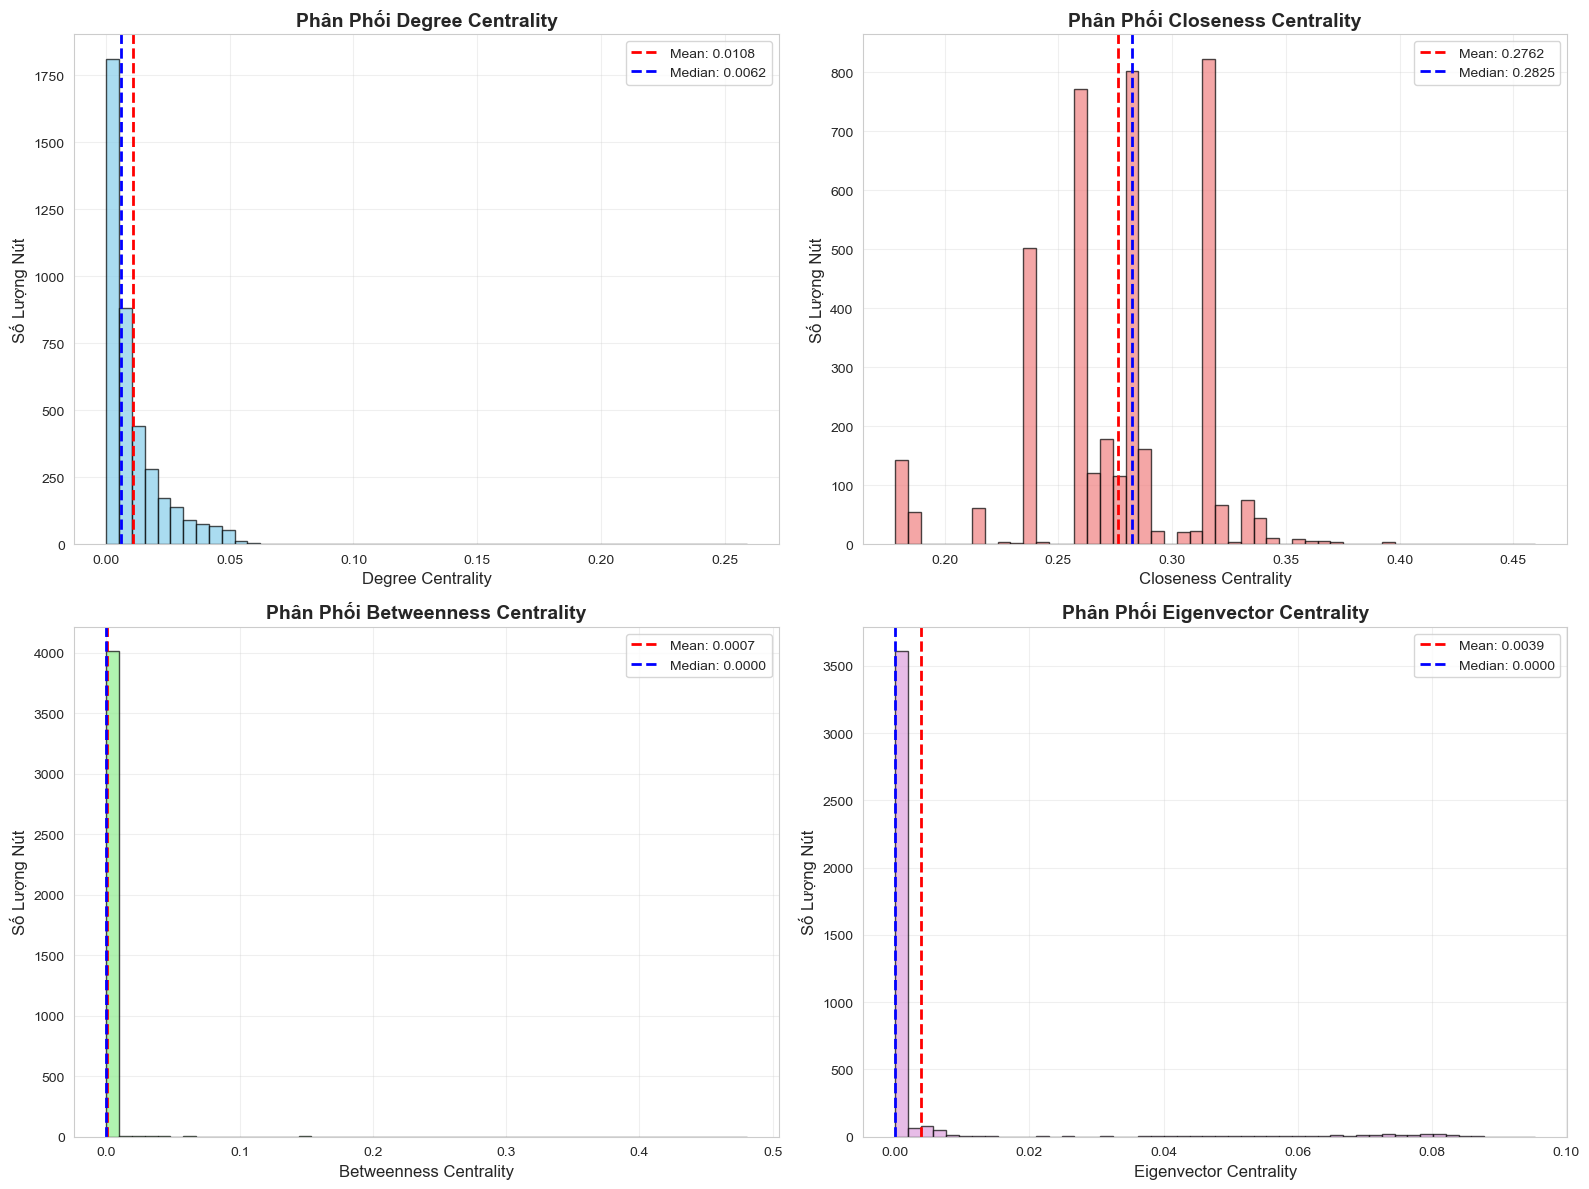

In [6]:
# Vẽ phân phối các độ đo
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

measures = [
    ('degree_centrality', 'Degree Centrality', 'skyblue'),
    ('closeness_centrality', 'Closeness Centrality', 'lightcoral'),
    ('betweenness_centrality', 'Betweenness Centrality', 'lightgreen'),
    ('eigenvector_centrality', 'Eigenvector Centrality', 'plum')
]

for idx, (column, title, color) in enumerate(measures):
    ax = axes[idx // 2, idx % 2]
    
    # Histogram
    ax.hist(centrality_df[column], bins=50, color=color, edgecolor='black', alpha=0.7)
    ax.axvline(centrality_df[column].mean(), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {centrality_df[column].mean():.4f}')
    ax.axvline(centrality_df[column].median(), color='blue', linestyle='--', 
               linewidth=2, label=f'Median: {centrality_df[column].median():.4f}')
    
    ax.set_xlabel(title, fontsize=12)
    ax.set_ylabel('Số Lượng Nút', fontsize=12)
    ax.set_title(f'Phân Phối {title}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. PageRank và HITS (Cho Mạng Có Hướng)

In [7]:
print("\n" + "="*70)
print("PAGERANK VÀ HITS")
print("="*70)

# Chuyển thành đồ thị có hướng nếu cần (để demo)
if not G.is_directed():
    print("\nĐồ thị hiện tại là vô hướng. Tạo phiên bản có hướng để tính PageRank/HITS...")
    G_directed = G.to_directed()
else:
    G_directed = G

# PageRank
print("\n1. Tính PageRank...")
pagerank = nx.pagerank(G_directed, alpha=0.85)
centrality_df['pagerank'] = [pagerank[n] for n in centrality_df['node']]

# HITS
print("2. Tính HITS (Hubs and Authorities)...")
hits = nx.hits(G_directed, max_iter=1000)
hubs = hits[0]
authorities = hits[1]

centrality_df['hub_score'] = [hubs[n] for n in centrality_df['node']]
centrality_df['authority_score'] = [authorities[n] for n in centrality_df['node']]

print("\n✓ Hoàn thành tính toán PageRank và HITS!")


PAGERANK VÀ HITS

Đồ thị hiện tại là vô hướng. Tạo phiên bản có hướng để tính PageRank/HITS...

1. Tính PageRank...

1. Tính PageRank...
2. Tính HITS (Hubs and Authorities)...
2. Tính HITS (Hubs and Authorities)...

✓ Hoàn thành tính toán PageRank và HITS!

✓ Hoàn thành tính toán PageRank và HITS!


In [8]:
# Top nodes theo PageRank và HITS
print("\n" + "="*70)
print("TOP 10 NÚT THEO PAGERANK VÀ HITS")
print("="*70)

print("\nTop 10 theo PageRank:")
top_pagerank = centrality_df.nlargest(10, 'pagerank')[['name', 'type', 'degree', 'pagerank']]
for idx, row in top_pagerank.iterrows():
    print(f"  {row['name']:20s} | Type: {row['type']:10s} | Degree: {row['degree']:4d} | PageRank: {row['pagerank']:.6f}")

print("\nTop 10 Hub Scores (HITS):")
top_hubs = centrality_df.nlargest(10, 'hub_score')[['name', 'type', 'degree', 'hub_score']]
for idx, row in top_hubs.iterrows():
    print(f"  {row['name']:20s} | Type: {row['type']:10s} | Degree: {row['degree']:4d} | Hub: {row['hub_score']:.6f}")

print("\nTop 10 Authority Scores (HITS):")
top_authorities = centrality_df.nlargest(10, 'authority_score')[['name', 'type', 'degree', 'authority_score']]
for idx, row in top_authorities.iterrows():
    print(f"  {row['name']:20s} | Type: {row['type']:10s} | Degree: {row['degree']:4d} | Authority: {row['authority_score']:.6f}")

print("""
GIẢI THÍCH:
- PageRank: Đo lường tầm quan trọng dựa trên số lượng và chất lượng liên kết đến
- Hub Score: Nút trỏ đến nhiều nút quan trọng (nguồn thông tin tốt)
- Authority Score: Nút được nhiều nút quan trọng trỏ đến (nguồn đáng tin cậy)
""")


TOP 10 NÚT THEO PAGERANK VÀ HITS

Top 10 theo PageRank:
  User_3437            | Type: Unknown    | Degree:  547 | PageRank: 0.007615
  User_107             | Type: Unknown    | Degree: 1045 | PageRank: 0.006936
  User_1684            | Type: Unknown    | Degree:  792 | PageRank: 0.006367
  User_0               | Type: Unknown    | Degree:  347 | PageRank: 0.006290
  User_1912            | Type: Unknown    | Degree:  755 | PageRank: 0.003877
  User_348             | Type: Unknown    | Degree:  229 | PageRank: 0.002348
  User_686             | Type: Unknown    | Degree:  170 | PageRank: 0.002219
  User_3980            | Type: Unknown    | Degree:   59 | PageRank: 0.002170
  User_414             | Type: Unknown    | Degree:  159 | PageRank: 0.001800
  User_698             | Type: Unknown    | Degree:   68 | PageRank: 0.001317

Top 10 Hub Scores (HITS):
  User_1912            | Type: Unknown    | Degree:  755 | Hub: 0.006117
  User_2266            | Type: Unknown    | Degree:  234 | Hub:

## 6. So Sánh Tương Quan Các Độ Đo Trung Tâm

In [9]:
# Tính ma trận tương quan
centrality_columns = ['degree_centrality', 'closeness_centrality', 
                      'betweenness_centrality', 'eigenvector_centrality',
                      'pagerank', 'hub_score', 'authority_score']

correlation_matrix = centrality_df[centrality_columns].corr(method='spearman')

print("\n" + "="*70)
print("MA TRẬN TƯƠNG QUAN (SPEARMAN) CÁC ĐỘ ĐO TRUNG TÂM")
print("="*70)
print(correlation_matrix.round(3))


MA TRẬN TƯƠNG QUAN (SPEARMAN) CÁC ĐỘ ĐO TRUNG TÂM
                        degree_centrality  closeness_centrality  \
degree_centrality                   1.000                 0.430   
closeness_centrality                0.430                 1.000   
betweenness_centrality              0.788                 0.479   
eigenvector_centrality              0.529                 0.458   
pagerank                            0.838                 0.234   
hub_score                           0.527                 0.448   
authority_score                     0.527                 0.448   

                        betweenness_centrality  eigenvector_centrality  \
degree_centrality                        0.788                   0.529   
closeness_centrality                     0.479                   0.458   
betweenness_centrality                   1.000                   0.408   
eigenvector_centrality                   0.408                   1.000   
pagerank                                 0

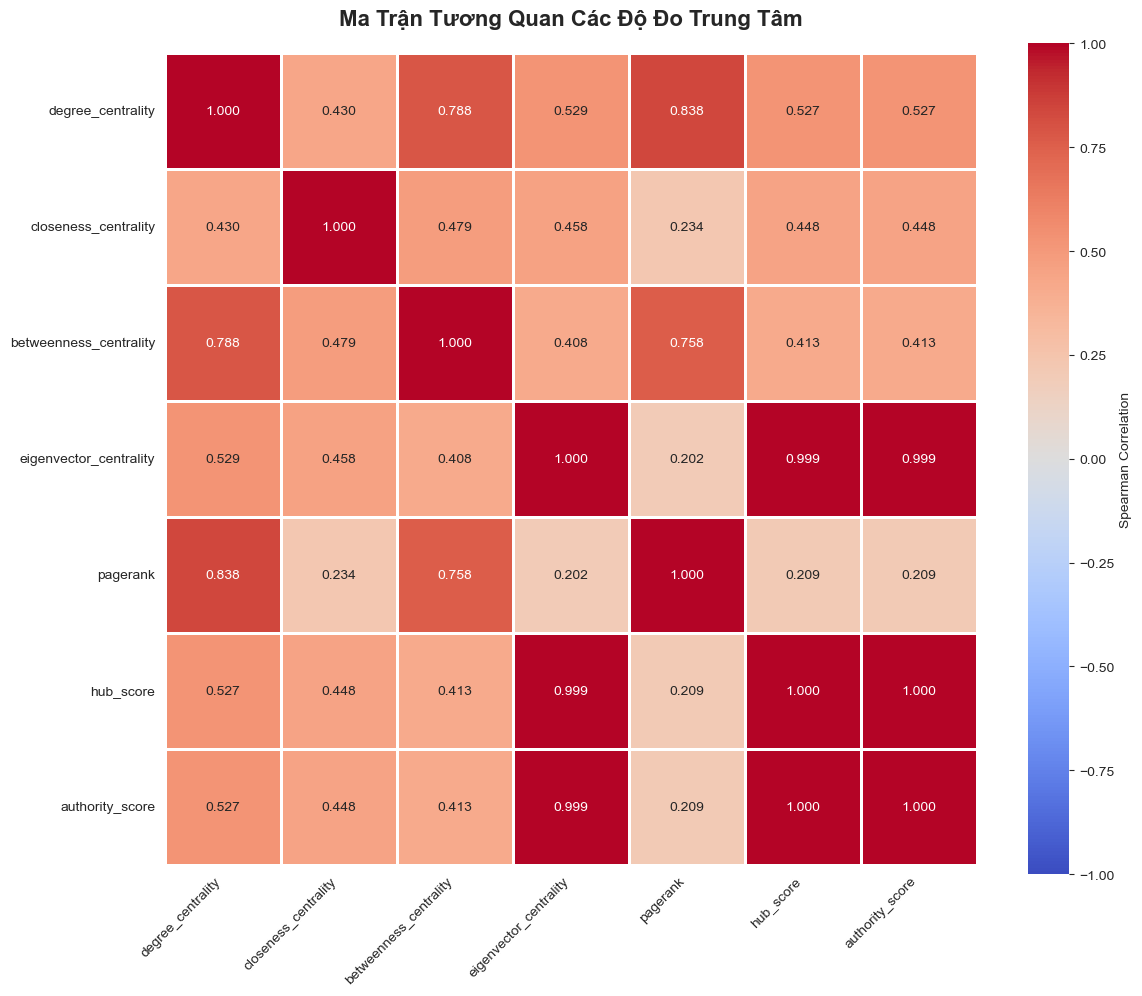


PHÂN TÍCH TƯƠNG QUAN

Các cặp độ đo có tương quan cao (|r| > 0.7):
  hub_score                 ↔ authority_score          : +1.000
  eigenvector_centrality    ↔ hub_score                : +0.999
  eigenvector_centrality    ↔ authority_score          : +0.999
  degree_centrality         ↔ pagerank                 : +0.838
  degree_centrality         ↔ betweenness_centrality   : +0.788
  betweenness_centrality    ↔ pagerank                 : +0.758

➤ NHẬN XÉT:
  - Tương quan cao (> 0.7): Các độ đo phản ánh cùng khía cạnh trung tâm
  - Tương quan thấp (< 0.3): Các độ đo bổ sung thông tin cho nhau
  - Tương quan âm: Các nút trung tâm theo độ đo này thường không trung tâm theo độ đo kia



In [10]:
# Vẽ heatmap tương quan
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=1,
            cbar_kws={'label': 'Spearman Correlation'})
plt.title('Ma Trận Tương Quan Các Độ Đo Trung Tâm', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Phân tích tương quan
print("\n" + "="*70)
print("PHÂN TÍCH TƯƠNG QUAN")
print("="*70)

high_corr_pairs = []
for i in range(len(centrality_columns)):
    for j in range(i+1, len(centrality_columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.7:
            high_corr_pairs.append((centrality_columns[i], centrality_columns[j], corr))

if high_corr_pairs:
    print("\nCác cặp độ đo có tương quan cao (|r| > 0.7):")
    for measure1, measure2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {measure1:25s} ↔ {measure2:25s}: {corr:+.3f}")
else:
    print("\nKhông có cặp độ đo nào có tương quan cao (|r| > 0.7)")

print("""
➤ NHẬN XÉT:
  - Tương quan cao (> 0.7): Các độ đo phản ánh cùng khía cạnh trung tâm
  - Tương quan thấp (< 0.3): Các độ đo bổ sung thông tin cho nhau
  - Tương quan âm: Các nút trung tâm theo độ đo này thường không trung tâm theo độ đo kia
""")

## 7. Sắp Xếp và Phân Tích Nút Theo Thuộc Tính

In [11]:
# Phân tích theo loại nút
print("\n" + "="*70)
print("PHÂN TÍCH TRUNG TÂM THEO LOẠI NÚT")
print("="*70)

type_analysis = centrality_df.groupby('type')[centrality_columns].agg(['mean', 'median', 'std'])
print("\nThống kê các độ đo trung tâm theo loại nút:")
print(type_analysis.round(4))


PHÂN TÍCH TRUNG TÂM THEO LOẠI NÚT

Thống kê các độ đo trung tâm theo loại nút:
        degree_centrality                closeness_centrality                  \
                     mean  median    std                 mean  median     std   
type                                                                            
Unknown            0.0108  0.0062  0.013               0.2762  0.2825  0.0361   

        betweenness_centrality                eigenvector_centrality         \
                          mean median     std                   mean median   
type                                                                          
Unknown                 0.0007    0.0  0.0116                 0.0039    0.0   

                pagerank                 hub_score                \
            std     mean  median     std      mean median    std   
type                                                               
Unknown  0.0153   0.0002  0.0002  0.0003    0.0002    0.0  0.001   

     

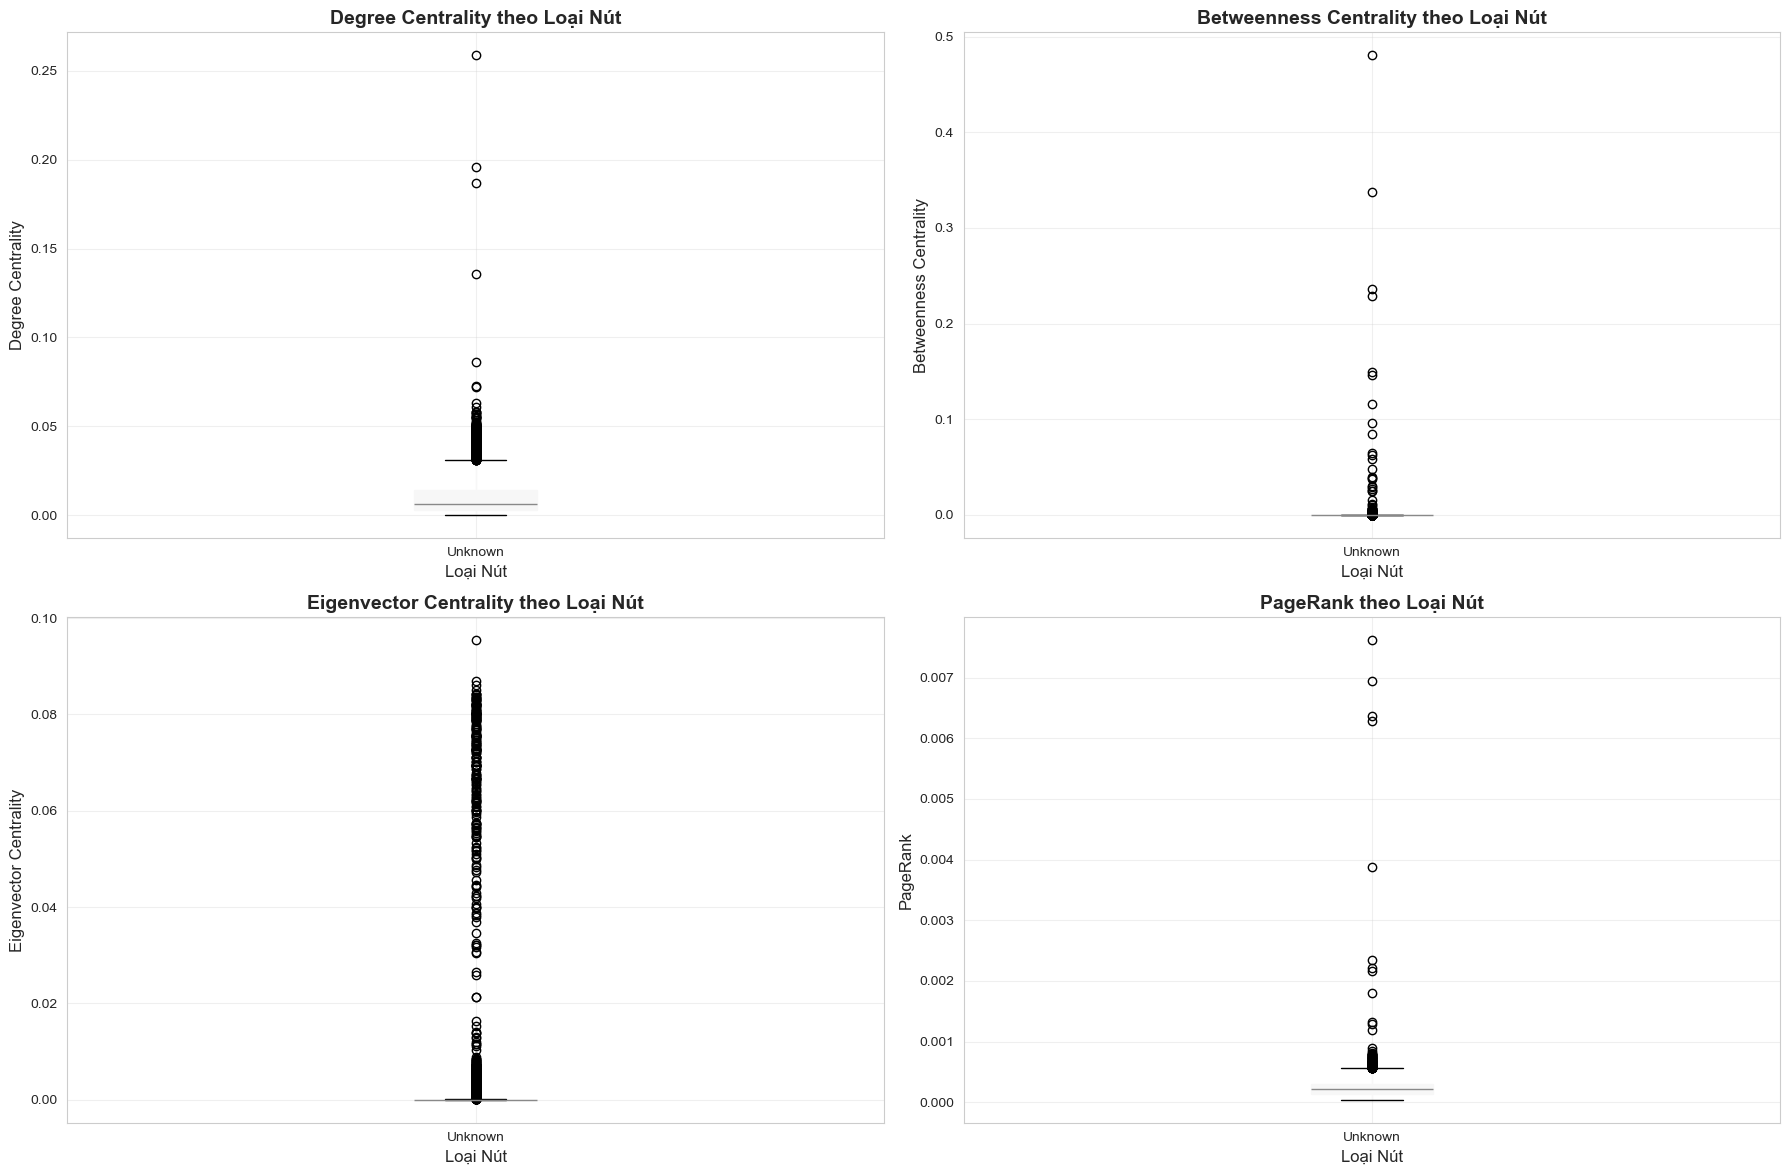

In [12]:
# Vẽ boxplot so sánh
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

plot_measures = [
    ('degree_centrality', 'Degree Centrality'),
    ('betweenness_centrality', 'Betweenness Centrality'),
    ('eigenvector_centrality', 'Eigenvector Centrality'),
    ('pagerank', 'PageRank')
]

for idx, (column, title) in enumerate(plot_measures):
    ax = axes[idx // 2, idx % 2]
    
    centrality_df.boxplot(column=column, by='type', ax=ax, patch_artist=True)
    ax.set_xlabel('Loại Nút', fontsize=12)
    ax.set_ylabel(title, fontsize=12)
    ax.set_title(f'{title} theo Loại Nút', fontsize=14, fontweight='bold')
    ax.get_figure().suptitle('')  # Remove default title
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Ranking tổng hợp - tính điểm tổng hợp từ các độ đo
print("\n" + "="*70)
print("RANKING TỔNG HỢP")
print("="*70)

# Chuẩn hóa các độ đo về [0, 1]
scaler = StandardScaler()
normalized_measures = centrality_df[centrality_columns].copy()
for col in centrality_columns:
    min_val = normalized_measures[col].min()
    max_val = normalized_measures[col].max()
    normalized_measures[col] = (normalized_measures[col] - min_val) / (max_val - min_val)

# Tính điểm tổng hợp (trung bình có trọng số hoặc đơn giản)
centrality_df['composite_score'] = normalized_measures.mean(axis=1)

# Top 20 nút quan trọng nhất
print("\nTop 20 nút quan trọng nhất (dựa trên điểm tổng hợp):")
top_composite = centrality_df.nlargest(20, 'composite_score')
print(top_composite[['name', 'type', 'degree', 'composite_score']].to_string(index=False))


RANKING TỔNG HỢP

Top 20 nút quan trọng nhất (dựa trên điểm tổng hợp):
     name    type  degree  composite_score
User_1912 Unknown     755         0.759923
 User_107 Unknown    1045         0.559527
User_2266 Unknown     234         0.483432
User_2347 Unknown     291         0.465896
User_2206 Unknown     210         0.464736
User_2233 Unknown     222         0.463324
User_2142 Unknown     221         0.458899
User_2218 Unknown     205         0.455379
User_2464 Unknown     202         0.455290
User_2078 Unknown     204         0.455072
User_1985 Unknown     224         0.452969
User_2410 Unknown     207         0.452951
User_2123 Unknown     203         0.452792
User_1993 Unknown     203         0.452285
User_2229 Unknown     207         0.450769
User_2244 Unknown     200         0.450749
User_2507 Unknown     201         0.450685
User_2240 Unknown     201         0.449692
User_2340 Unknown     198         0.449100
User_2088 Unknown     198         0.446549


## 8. Phân Tích Tính Tương Đương Cấu Trúc (Structural Equivalence)

In [14]:
print("\n" + "="*70)
print("PHÂN TÍCH TÍNH TƯƠNG ĐƯƠNG CẤU TRÚC")
print("="*70)

# Tính ma trận kề
adj_matrix = nx.to_numpy_array(G)

# Tính độ tương đồng Jaccard giữa các nút dựa trên láng giềng
print("\nTính độ tương đồng cấu trúc giữa các nút...")

# Lấy mẫu nếu đồ thị quá lớn
sample_size = min(100, len(G))
sample_nodes = np.random.choice(list(G.nodes()), size=sample_size, replace=False)

similarity_matrix = np.zeros((sample_size, sample_size))

for i, node1 in enumerate(sample_nodes):
    neighbors1 = set(G.neighbors(node1))
    for j, node2 in enumerate(sample_nodes):
        if i <= j:
            neighbors2 = set(G.neighbors(node2))
            # Tính Jaccard similarity
            intersection = len(neighbors1 & neighbors2)
            union = len(neighbors1 | neighbors2)
            similarity = intersection / union if union > 0 else 0
            similarity_matrix[i, j] = similarity
            similarity_matrix[j, i] = similarity

print(f"\nĐã tính ma trận tương đồng cho {sample_size} nút mẫu")


PHÂN TÍCH TÍNH TƯƠNG ĐƯƠNG CẤU TRÚC

Tính độ tương đồng cấu trúc giữa các nút...

Đã tính ma trận tương đồng cho 100 nút mẫu

Tính độ tương đồng cấu trúc giữa các nút...

Đã tính ma trận tương đồng cho 100 nút mẫu


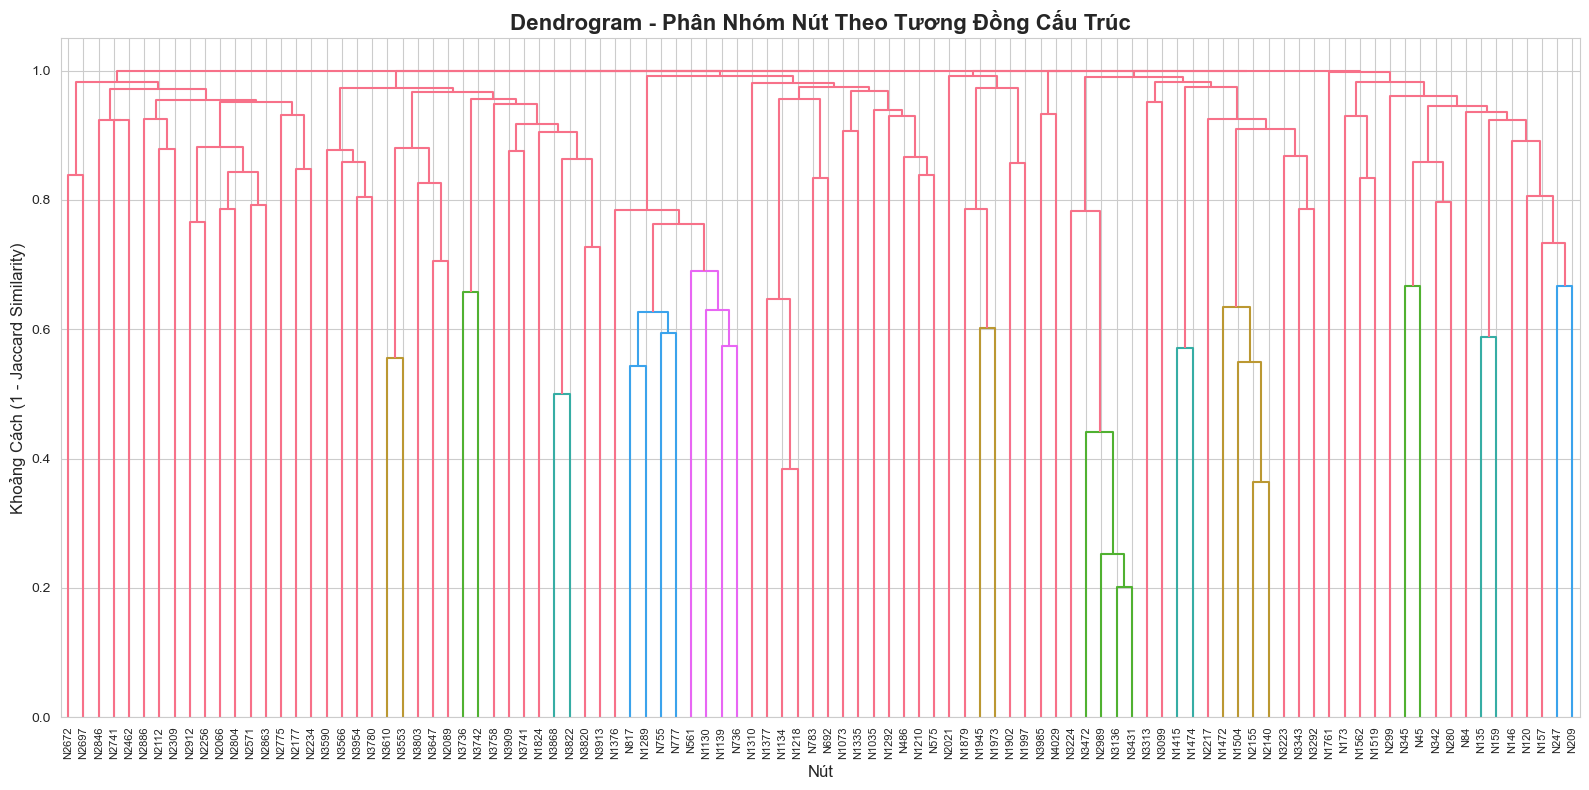


➤ GIẢI THÍCH:
  - Các nút có cấu trúc láng giềng tương tự sẽ được nhóm lại gần nhau
  - Dendrogram cho thấy cấu trúc phân cấp của sự tương đồng
  - Các nút trong cùng một nhóm có vai trò cấu trúc tương tự trong mạng



In [15]:
# Hierarchical clustering dựa trên tương đồng cấu trúc
from scipy.spatial.distance import squareform

# Chuyển similarity thành distance
distance_matrix = 1 - similarity_matrix

# Lấy upper triangle của ma trận khoảng cách
condensed_distance = squareform(distance_matrix, checks=False)

# Hierarchical clustering
linkage_matrix = linkage(condensed_distance, method='average')

# Vẽ dendrogram
plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix, labels=[f"N{n}" for n in sample_nodes], 
           leaf_font_size=8, leaf_rotation=90)
plt.title('Dendrogram - Phân Nhóm Nút Theo Tương Đồng Cấu Trúc', 
          fontsize=16, fontweight='bold')
plt.xlabel('Nút', fontsize=12)
plt.ylabel('Khoảng Cách (1 - Jaccard Similarity)', fontsize=12)
plt.tight_layout()
plt.show()

print("""
➤ GIẢI THÍCH:
  - Các nút có cấu trúc láng giềng tương tự sẽ được nhóm lại gần nhau
  - Dendrogram cho thấy cấu trúc phân cấp của sự tương đồng
  - Các nút trong cùng một nhóm có vai trò cấu trúc tương tự trong mạng
""")

## 9. Xuất Kết Quả

In [16]:
# Xuất bảng centrality ra file CSV
output_file = '../data/centrality_analysis.csv'
centrality_df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f"\nĐã xuất kết quả phân tích centrality ra: {output_file}")

# Xuất correlation matrix
correlation_file = '../data/centrality_correlation.csv'
correlation_matrix.to_csv(correlation_file, encoding='utf-8-sig')
print(f"Đã xuất ma trận tương quan ra: {correlation_file}")


Đã xuất kết quả phân tích centrality ra: ../data/centrality_analysis.csv
Đã xuất ma trận tương quan ra: ../data/centrality_correlation.csv
